# 🌡️ Urban Heat Island (UHI) Analysis — Research Paper Code


**Dataset:** [Daily Delhi Climate Time Series](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data)  
Dataset name- `DailyDelhiClimateTrain.csv`



## ⚙️ Setup — Install & Import Libraries

In [6]:
# Install any missing packages (Colab usually has these)
# !pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Create output folder
os.makedirs('outputs/charts', exist_ok=True)
print('Libraries loaded and output folders created ✓')

Libraries loaded and output folders created ✓


---
## 📅  — Data Acquisition & Cleaning
**Topics:** Load data, Remove NA, Impute values, Encode, Detect outliers, Normalize and transform

In [7]:
# --- STEP 1: Load the dataset ---
# Make sure DailyDelhiClimateTrain.csv is uploaded to Colab
df = pd.read_csv('/content/DailyDelhiClimateTest.csv')


print(f'Raw dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
display(df.head())
print(f'\nColumn data types:')
print(df.dtypes)

Raw dataset shape: (114, 5)

First 5 rows:


,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333



Column data types:
date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object


In [8]:
# --- STEP 2: Handle Inappropriate / Wrong Data ---
df['meantemp'] = df['meantemp'].replace(0, np.nan)
df['humidity'] = df['humidity'].replace(0, np.nan)
print(f'Missing values BEFORE cleaning:')
print(df.isnull().sum())

# --- STEP 3: Impute Missing Values (mean imputation) ---
df['meantemp'].fillna(df['meantemp'].mean(), inplace=True)
df['humidity'].fillna(df['humidity'].mean(), inplace=True)
df['wind_speed'].fillna(df['wind_speed'].mean(), inplace=True)
df['meanpressure'].fillna(df['meanpressure'].mean(), inplace=True)
print(f'\nMissing values AFTER cleaning:')
print(df.isnull().sum())

Missing values BEFORE cleaning:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Missing values AFTER cleaning:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


In [9]:
# --- STEP 4: Parse Dates + Extract Time Features ---
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['season'] = pd.cut(
    df['month'],
    bins=[0, 2, 5, 8, 11, 12],
    labels=['Winter', 'Spring', 'Summer', 'Monsoon', 'Winter'],
    ordered=False
)
print('Date parsing complete. Sample:')
display(df[['date','month','year','season']].head(8))

Date parsing complete. Sample:


,date,month,year,season
0,2017-01-01,1,2017,Winter
1,2017-01-02,1,2017,Winter
2,2017-01-03,1,2017,Winter
3,2017-01-04,1,2017,Winter
4,2017-01-05,1,2017,Winter
5,2017-01-06,1,2017,Winter
6,2017-01-07,1,2017,Winter
7,2017-01-08,1,2017,Winter


In [10]:
# --- STEP 5: Simulate Multi-City Data for UHI Comparison ---
# We replicate Delhi data and apply realistic temperature offsets
# to simulate Mumbai, Ahmedabad, Bangalore, Chennai, Kolkata

np.random.seed(42)
cities = {
    'Delhi':      {'temp_offset': 0,    'humidity_factor': 1.0},
    'Ahmedabad':  {'temp_offset': 2.5,  'humidity_factor': 0.85},
    'Mumbai':     {'temp_offset': -1.5, 'humidity_factor': 1.3},
    'Chennai':    {'temp_offset': 1.8,  'humidity_factor': 1.25},
    'Bangalore':  {'temp_offset': -3.5, 'humidity_factor': 1.1},
    'Kolkata':    {'temp_offset': 1.2,  'humidity_factor': 1.15},
}

city_dfs = []
for city, params in cities.items():
    city_df = df.copy()
    city_df['city'] = city
    city_df['meantemp'] = (
        city_df['meantemp']
        + params['temp_offset']
        + np.random.normal(0, 0.8, len(city_df))
    )
    city_df['humidity'] = np.clip(
        city_df['humidity'] * params['humidity_factor']
        + np.random.normal(0, 2, len(city_df)),
        10, 100
    )
    greenery_map = {
        'Bangalore': 0.72, 'Mumbai': 0.51, 'Kolkata': 0.48,
        'Delhi': 0.38, 'Chennai': 0.35, 'Ahmedabad': 0.28
    }
    city_df['greenery_index'] = (
        greenery_map[city] + np.random.normal(0, 0.03, len(city_df))
    )
    city_dfs.append(city_df)

df_all = pd.concat(city_dfs, ignore_index=True)
print(f'Multi-city dataset shape: {df_all.shape}')
print(f'Cities: {df_all["city"].unique()}')

Multi-city dataset shape: (684, 10)
Cities: ['Delhi' 'Ahmedabad' 'Mumbai' 'Chennai' 'Bangalore' 'Kolkata']


In [11]:
# --- STEP 6: Label Encoding for city column ---
le = LabelEncoder()
df_all['city_encoded'] = le.fit_transform(df_all['city'])
city_label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'Label Encoding map: {city_label_map}')

# --- STEP 7: One-Hot Encoding for season ---
df_all['season'] = df_all['season'].astype(str)
season_dummies = pd.get_dummies(df_all['season'], prefix='season')
df_all = pd.concat([df_all, season_dummies], axis=1)
print(f'\nColumns added by one-hot encoding: {list(season_dummies.columns)}')

Label Encoding map: {'Ahmedabad': np.int64(0), 'Bangalore': np.int64(1), 'Chennai': np.int64(2), 'Delhi': np.int64(3), 'Kolkata': np.int64(4), 'Mumbai': np.int64(5)}

Columns added by one-hot encoding: ['season_Spring', 'season_Winter']


In [12]:
# --- STEP 8: Outlier Detection using IQR ---
print('Outlier detection using IQR method:')
for col in ['meantemp', 'humidity', 'wind_speed']:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_all[col] < lower) | (df_all[col] > upper)).sum()
    print(f'  {col}: {n_outliers} outliers (range: {lower:.2f} - {upper:.2f})')
    df_all[col] = np.clip(df_all[col], lower, upper)

# --- STEP 9: Data Normalization ---
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

df_all[['temp_standardized']] = scaler_std.fit_transform(df_all[['meantemp']])
df_all[['temp_normalized']] = scaler_mm.fit_transform(df_all[['meantemp']])

print(f'\nStandardized temp — mean: {df_all["temp_standardized"].mean():.4f}, '
      f'std: {df_all["temp_standardized"].std():.4f}')
print(f'Normalized temp  — min: {df_all["temp_normalized"].min():.4f}, '
      f'max: {df_all["temp_normalized"].max():.4f}')

# Save cleaned dataset
df_all.to_csv('outputs/uhi_cleaned_data.csv', index=False)
print('\n✓ Week 1 complete. Cleaned data saved to outputs/uhi_cleaned_data.csv')

Outlier detection using IQR method:
  meantemp: 0 outliers (range: 0.99 - 43.00)
  humidity: 0 outliers (range: -12.43 - 136.57)
  wind_speed: 12 outliers (range: -1.21 - 16.85)

Standardized temp — mean: -0.0000, std: 1.0007
Normalized temp  — min: 0.0000, max: 1.0000

✓ Week 1 complete. Cleaned data saved to outputs/uhi_cleaned_data.csv


---
## 📅 Week 2 — Data Wrangling
**Topics:** Conditional statements, Drop columns, Rename, Change types, Date data, GroupBy, Sorting, Concatenate, Merge, Join

In [13]:
# --- Drop columns we don't need ---
df_work = df_all.drop(columns=['temp_standardized', 'temp_normalized'])
print(f'Columns after dropping scaled cols: {list(df_work.columns)}')

# --- Rename columns for clarity ---
df_work = df_work.rename(columns={
    'meantemp': 'avg_temp',
    'wind_speed': 'wind_spd',
    'meanpressure': 'pressure'
})

# --- Change column type ---
df_work['city_encoded'] = df_work['city_encoded'].astype('int8')

# --- Conditional column: UHI risk category ---
def uhi_risk(temp):
    if temp >= 32:
        return 'High'
    elif temp >= 27:
        return 'Medium'
    else:
        return 'Low'

df_work['uhi_risk'] = df_work['avg_temp'].apply(uhi_risk)
print(f'\nUHI Risk distribution:')
print(df_work['uhi_risk'].value_counts())

Columns after dropping scaled cols: ['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure', 'month', 'year', 'season', 'city', 'greenery_index', 'city_encoded', 'season_Spring', 'season_Winter']

UHI Risk distribution:
uhi_risk
Low       504
Medium    119
High       61
Name: count, dtype: int64


In [14]:
# --- Date-related computations ---
df_work['is_summer'] = df_work['month'].isin([4, 5, 6]).astype(int)
df_work['is_monsoon'] = df_work['month'].isin([7, 8, 9]).astype(int)

# --- GroupBy: city-wise summary ---
city_summary = df_work.groupby('city').agg(
    avg_temperature=('avg_temp', 'mean'),
    max_temperature=('avg_temp', 'max'),
    min_temperature=('avg_temp', 'min'),
    avg_humidity=('humidity', 'mean'),
    avg_wind=('wind_spd', 'mean'),
    avg_greenery=('greenery_index', 'mean'),
    total_records=('avg_temp', 'count')
).round(2).reset_index()

city_summary = city_summary.sort_values('avg_temperature', ascending=False)
print('City-wise summary (sorted by temperature):')
display(city_summary)

# --- Monthly groupby ---
monthly_summary = df_work.groupby(['city', 'month'])['avg_temp'].mean().round(2).reset_index()
monthly_summary.columns = ['city', 'month', 'avg_temp']

# Save for Power BI
city_summary.to_excel('outputs/city_summary_powerbi.xlsx', index=False)
monthly_summary.to_excel('outputs/monthly_trends_powerbi.xlsx', index=False)
print('\n✓ Week 2 complete. Excel files saved for Power BI.')

City-wise summary (sorted by temperature):


,city,avg_temperature,max_temperature,min_temperature,avg_humidity,avg_wind,avg_greenery,total_records
0,Ahmedabad,24.22,37.76,14.16,47.53,8.12,0.28,114
2,Chennai,23.63,37.07,11.82,69.71,8.12,0.35,114
4,Kolkata,22.87,35.34,12.49,64.57,8.12,0.48,114
3,Delhi,21.64,34.44,10.63,56.43,8.12,0.38,114
5,Mumbai,20.21,32.67,9.80,72.59,8.12,0.51,114
1,Bangalore,18.37,31.34,7.02,61.79,8.12,0.73,114



✓ Week 2 complete. Excel files saved for Power BI.


---
## 📅 Week 3 — EDA Process
**Topics:** Why EDA, Quantitative & qualitative analysis, Categorical variables handling, Feature scaling

In [15]:
# --- Numerical summary statistics ---
print('Quantitative analysis — numerical summary:')
display(df_work[['avg_temp', 'humidity', 'wind_spd', 'greenery_index']].describe().round(2))

# --- Qualitative analysis ---
print('\nQualitative analysis — categorical columns:')
print(f'Unique cities: {df_work["city"].nunique()}')
print(f'Unique seasons: {df_work["season"].unique()}')
print(f'\nRisk category counts:')
print(df_work['uhi_risk'].value_counts())
print(f'\nCity record counts:')
print(df_work['city'].value_counts())

# --- Feature scaling comparison ---
print('\nFeature Scaling comparison (StandardScaler vs MinMaxScaler):')
sample = df_work['avg_temp'].head(5).values.reshape(-1, 1)
std_scaled = StandardScaler().fit_transform(sample)
mm_scaled = MinMaxScaler().fit_transform(sample)
scale_compare = pd.DataFrame({
    'original': sample.flatten(),
    'standard_scaled': std_scaled.flatten().round(4),
    'minmax_scaled': mm_scaled.flatten().round(4)
})
display(scale_compare)
print('\n✓ Week 3 complete.')

Quantitative analysis — numerical summary:


,avg_temp,humidity,wind_spd,greenery_index
count,684.00,684.00,684.00,684.00
mean,21.82,62.10,8.12,0.46
std,6.70,22.47,3.50,0.15
min,7.02,14.11,1.39,0.20
25%,16.74,43.45,5.56,0.35
50%,20.52,62.07,8.07,0.43
75%,27.25,80.69,10.08,0.52
max,37.76,100.00,16.85,0.82



Qualitative analysis — categorical columns:
Unique cities: 6
Unique seasons: ['Winter' 'Spring']

Risk category counts:
uhi_risk
Low       504
Medium    119
High       61
Name: count, dtype: int64

City record counts:
city
Delhi        114
Ahmedabad    114
Mumbai       114
Chennai      114
Bangalore    114
Kolkata      114
Name: count, dtype: int64

Feature Scaling comparison (StandardScaler vs MinMaxScaler):


,original,standard_scaled,minmax_scaled
0,16.310415,-1.5231,0.0000
1,18.389389,0.2564,0.5762
2,17.629262,-0.3942,0.3655
3,19.918424,1.5652,1.0000
4,18.201566,0.0957,0.5242



✓ Week 3 complete.


---
## 📅 Week 4 — Univariate Analysis & Visualization
**Topics:** Histogram, Bar chart, Line plot, Pie chart, Box plot, Numerical summaries, matplotlib & seaborn

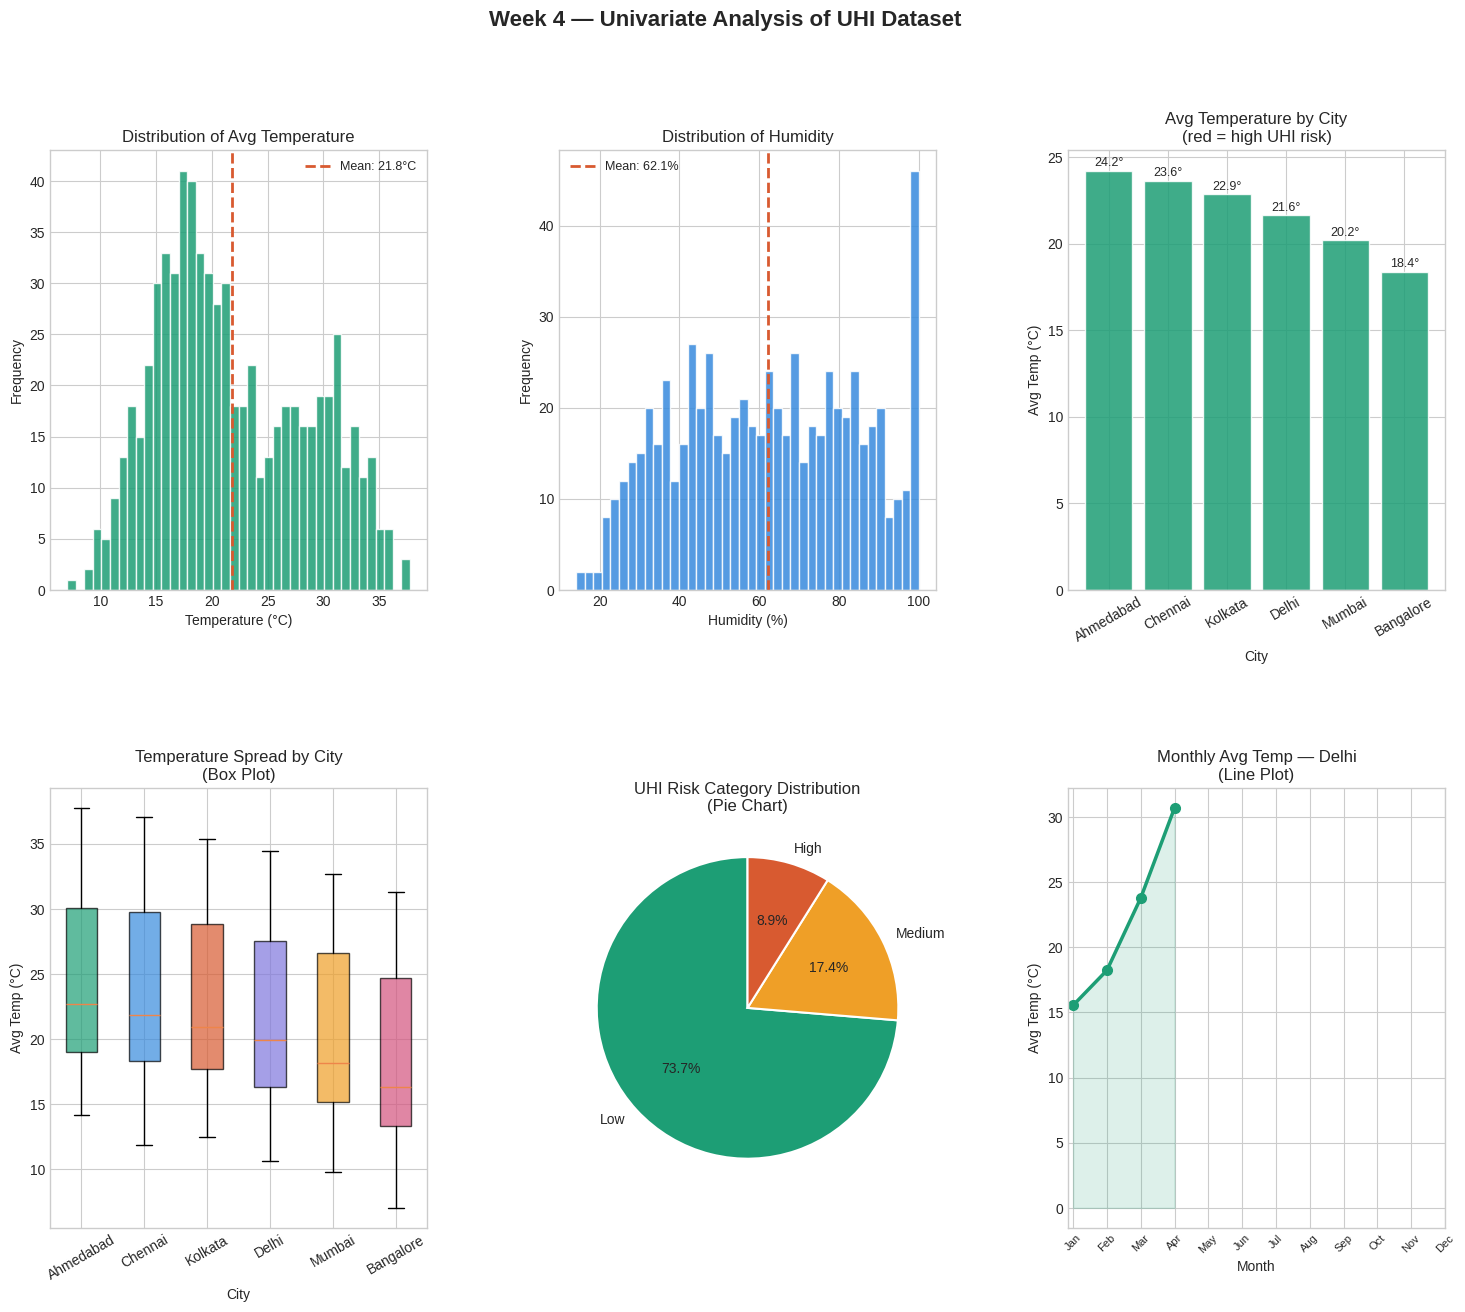


Numerical summaries for paper:
  avg_temp: mean=21.82, median=20.52, std=6.70, skew=0.348
  humidity: mean=62.10, median=62.07, std=22.47, skew=-0.010
  wind_spd: mean=8.12, median=8.07, std=3.50, skew=0.361

✓ Week 4 complete.


In [16]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Week 4 — Univariate Analysis of UHI Dataset',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: Histogram of avg temperature ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_work['avg_temp'], bins=40, color='#1D9E75', edgecolor='white', alpha=0.85)
ax1.axvline(df_work['avg_temp'].mean(), color='#D85A30', linestyle='--',
            linewidth=2, label=f"Mean: {df_work['avg_temp'].mean():.1f}°C")
ax1.set_title('Distribution of Avg Temperature', fontsize=12)
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Frequency')
ax1.legend(fontsize=9)

# --- Plot 2: Histogram of humidity ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_work['humidity'], bins=40, color='#378ADD', edgecolor='white', alpha=0.85)
ax2.axvline(df_work['humidity'].mean(), color='#D85A30', linestyle='--',
            linewidth=2, label=f"Mean: {df_work['humidity'].mean():.1f}%")
ax2.set_title('Distribution of Humidity', fontsize=12)
ax2.set_xlabel('Humidity (%)')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=9)

# --- Plot 3: Bar chart — city-wise avg temperature ---
ax3 = fig.add_subplot(gs[0, 2])
colors = ['#D85A30' if t >= 29 else '#1D9E75' for t in city_summary['avg_temperature']]
bars = ax3.bar(city_summary['city'], city_summary['avg_temperature'],
               color=colors, edgecolor='white', alpha=0.85)
ax3.set_title('Avg Temperature by City\n(red = high UHI risk)', fontsize=12)
ax3.set_xlabel('City')
ax3.set_ylabel('Avg Temp (°C)')
ax3.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, city_summary['avg_temperature']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}°', ha='center', va='bottom', fontsize=9)

# --- Plot 4: Box plot — temperature by city ---
ax4 = fig.add_subplot(gs[1, 0])
city_order = city_summary['city'].tolist()
bp_data = [df_work[df_work['city'] == c]['avg_temp'].values for c in city_order]
bp = ax4.boxplot(bp_data, labels=city_order, patch_artist=True, notch=False)
palette = ['#1D9E75', '#378ADD', '#D85A30', '#7F77DD', '#EF9F27', '#D4537E']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title('Temperature Spread by City\n(Box Plot)', fontsize=12)
ax4.set_xlabel('City')
ax4.set_ylabel('Avg Temp (°C)')
ax4.tick_params(axis='x', rotation=30)

# --- Plot 5: Pie chart — UHI Risk category split ---
ax5 = fig.add_subplot(gs[1, 1])
risk_counts = df_work['uhi_risk'].value_counts()
pie_colors = {'High': '#D85A30', 'Medium': '#EF9F27', 'Low': '#1D9E75'}
ax5.pie(risk_counts.values,
        labels=risk_counts.index,
        colors=[pie_colors[k] for k in risk_counts.index],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax5.set_title('UHI Risk Category Distribution\n(Pie Chart)', fontsize=12)

# --- Plot 6: Line plot — monthly avg temp (Delhi only) ---
ax6 = fig.add_subplot(gs[1, 2])
delhi_monthly = df_work[df_work['city'] == 'Delhi'].groupby('month')['avg_temp'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax6.plot(delhi_monthly.index, delhi_monthly.values,
         marker='o', color='#1D9E75', linewidth=2.5, markersize=7)
ax6.fill_between(delhi_monthly.index, delhi_monthly.values, alpha=0.15, color='#1D9E75')
ax6.set_title('Monthly Avg Temp — Delhi\n(Line Plot)', fontsize=12)
ax6.set_xlabel('Month')
ax6.set_ylabel('Avg Temp (°C)')
ax6.set_xticks(range(1, 13))
ax6.set_xticklabels(month_names, rotation=45, fontsize=8)

plt.savefig('outputs/charts/week4_univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nNumerical summaries for paper:')
for col in ['avg_temp', 'humidity', 'wind_spd']:
    s = df_work[col]
    print(f'  {col}: mean={s.mean():.2f}, median={s.median():.2f}, '
          f'std={s.std():.2f}, skew={s.skew():.3f}')
print('\n✓ Week 4 complete.')

---
## 📅 Week 5 — Bivariate & Multivariate Analysis
**Topics:** Continuous & categorical analysis, Aggregate plots, Pairwise relationships, Distributions across groups

In [17]:
# --- Correlation matrix ---
corr_cols = ['avg_temp', 'humidity', 'wind_spd', 'pressure', 'greenery_index']
corr = df_work[corr_cols].corr().round(3)
print('Correlation matrix:')
display(corr)

Correlation matrix:


,avg_temp,humidity,wind_spd,pressure,greenery_index
avg_temp,1.000,-0.785,0.202,0.029,-0.269
humidity,-0.785,1.000,-0.316,-0.082,0.138
wind_spd,0.202,-0.316,1.000,0.133,0.016
pressure,0.029,-0.082,0.133,1.000,-0.006
greenery_index,-0.269,0.138,0.016,-0.006,1.000


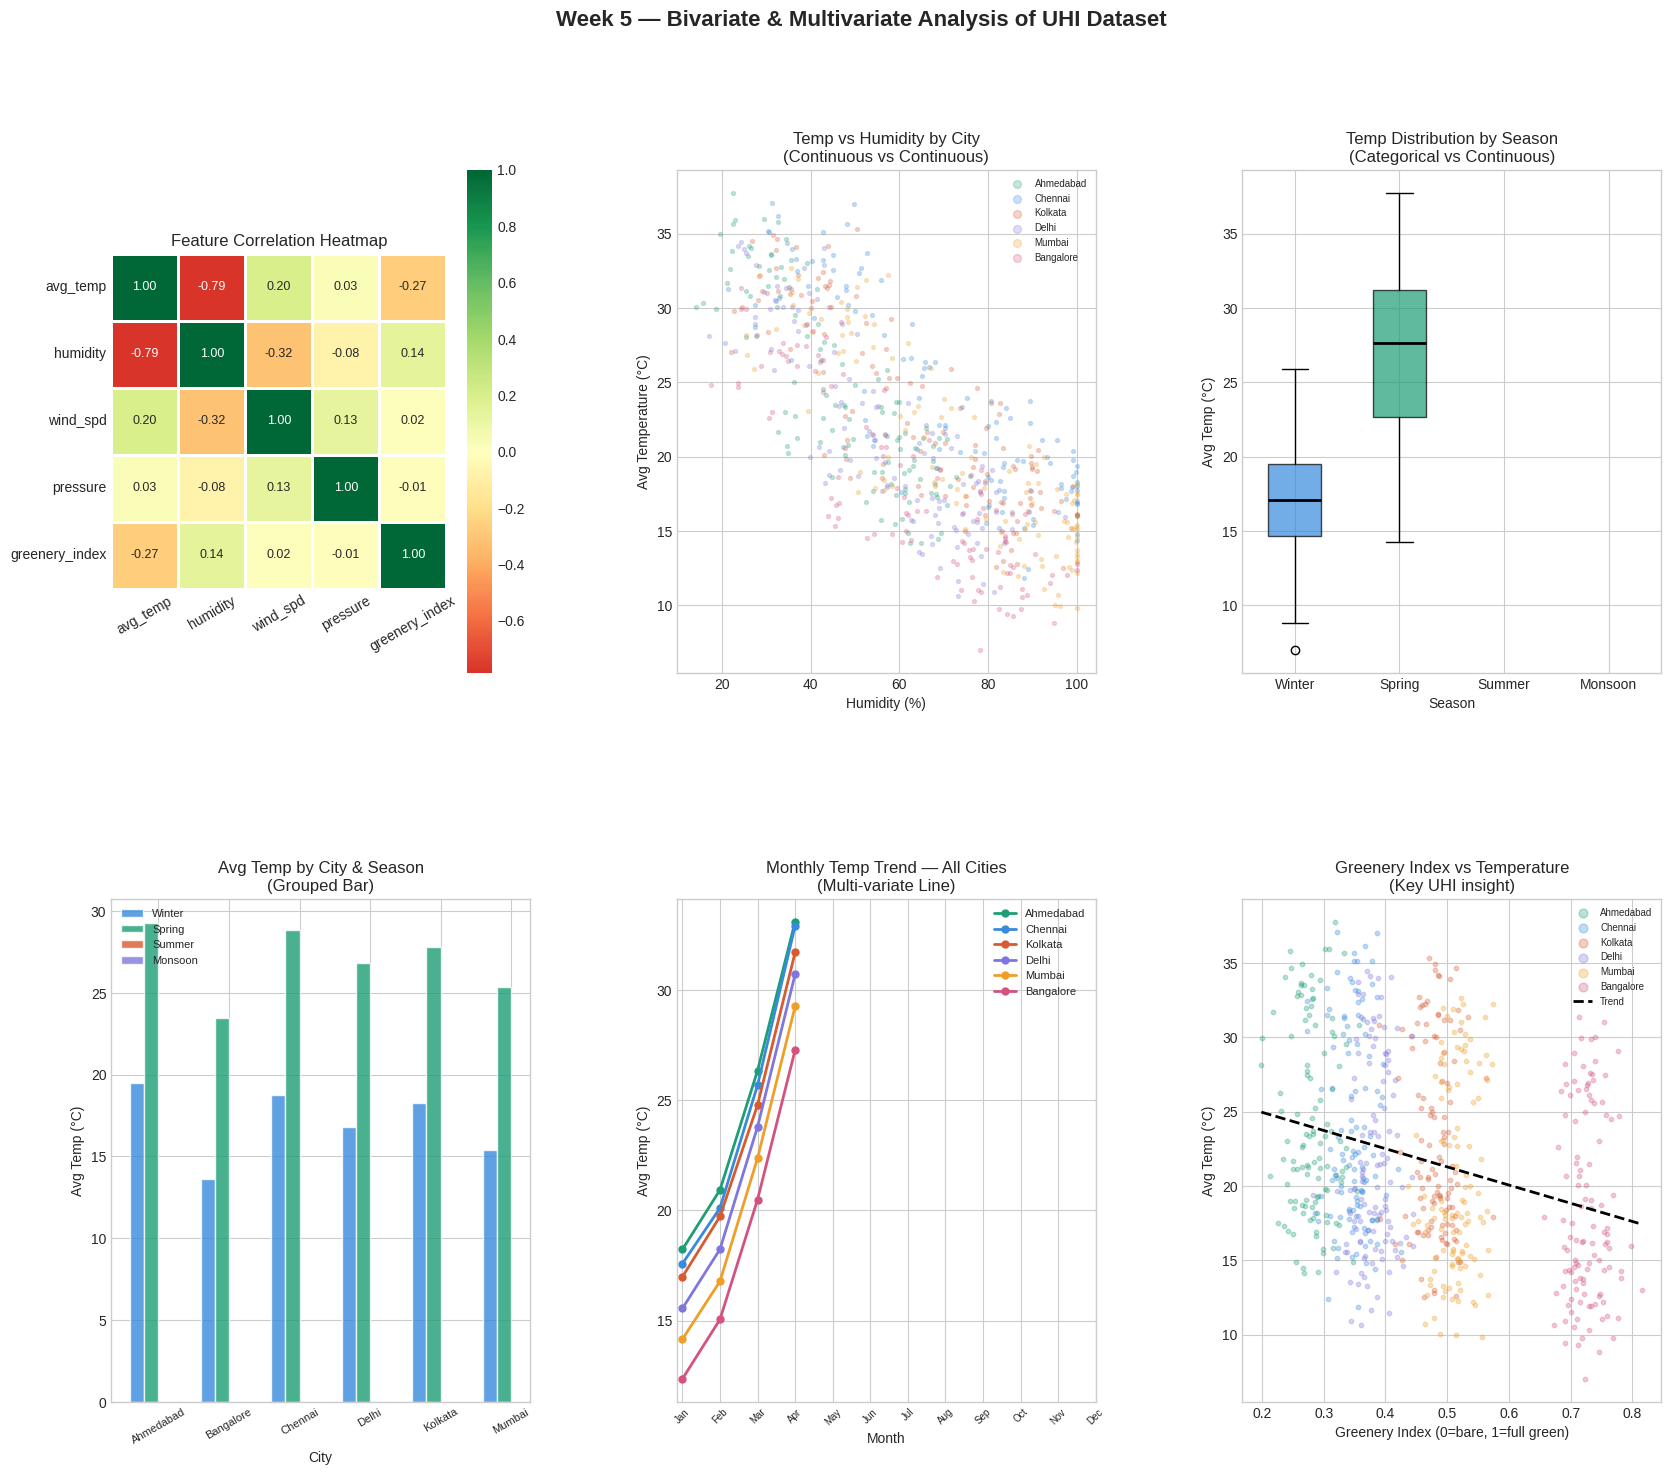


✓ Week 5 complete.


In [18]:
fig2 = plt.figure(figsize=(20, 16))
fig2.suptitle('Week 5 — Bivariate & Multivariate Analysis of UHI Dataset',
              fontsize=16, fontweight='bold', y=0.98)
gs2 = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.35)

# --- Plot 1: Heatmap (correlation) ---
ax1 = fig2.add_subplot(gs2[0, 0])
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax1, square=True, linewidths=0.8,
            annot_kws={'size': 9}, center=0)
ax1.set_title('Feature Correlation Heatmap', fontsize=12)
ax1.tick_params(axis='x', rotation=30)

# --- Plot 2: Scatter — temp vs humidity ---
ax2 = fig2.add_subplot(gs2[0, 1])
for i, city in enumerate(city_order):
    cdata = df_work[df_work['city'] == city]
    ax2.scatter(cdata['humidity'], cdata['avg_temp'],
                alpha=0.25, s=8, label=city, color=palette[i])
ax2.set_title('Temp vs Humidity by City\n(Continuous vs Continuous)', fontsize=12)
ax2.set_xlabel('Humidity (%)')
ax2.set_ylabel('Avg Temperature (°C)')
ax2.legend(fontsize=7, markerscale=2)

# --- Plot 3: Box plot — temp by season ---
ax3 = fig2.add_subplot(gs2[0, 2])
season_order = ['Winter', 'Spring', 'Summer', 'Monsoon']
season_colors = {'Winter': '#378ADD', 'Spring': '#1D9E75',
                 'Summer': '#D85A30', 'Monsoon': '#7F77DD'}
for i, season in enumerate(season_order):
    sdata = df_work[df_work['season'] == season]['avg_temp']
    bp2 = ax3.boxplot(sdata, positions=[i], patch_artist=True,
                      widths=0.5, notch=False,
                      boxprops=dict(facecolor=season_colors[season], alpha=0.7),
                      medianprops=dict(color='black', linewidth=2))
ax3.set_xticks(range(4))
ax3.set_xticklabels(season_order)
ax3.set_title('Temp Distribution by Season\n(Categorical vs Continuous)', fontsize=12)
ax3.set_xlabel('Season')
ax3.set_ylabel('Avg Temp (°C)')

# --- Plot 4: Grouped bar — avg temp by city and season ---
ax4 = fig2.add_subplot(gs2[1, 0])
season_city = df_work.groupby(['city', 'season'])['avg_temp'].mean().reset_index()
season_pivot = season_city.pivot(index='city', columns='season', values='avg_temp')
season_pivot = season_pivot.reindex(columns=season_order)
x = np.arange(len(season_pivot.index))
width = 0.2
for j, (season, color) in enumerate(season_colors.items()):
    if season in season_pivot.columns:
        ax4.bar(x + j * width, season_pivot[season], width,
                label=season, color=color, alpha=0.8, edgecolor='white')
ax4.set_title('Avg Temp by City & Season\n(Grouped Bar)', fontsize=12)
ax4.set_xlabel('City')
ax4.set_ylabel('Avg Temp (°C)')
ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(season_pivot.index, rotation=30, fontsize=8)
ax4.legend(fontsize=8)

# --- Plot 5: Line plot — monthly temp all cities ---
ax5 = fig2.add_subplot(gs2[1, 1])
for i, city in enumerate(city_order):
    cdata = df_work[df_work['city'] == city].groupby('month')['avg_temp'].mean()
    ax5.plot(cdata.index, cdata.values, marker='o', linewidth=2,
             markersize=5, label=city, color=palette[i])
ax5.set_title('Monthly Temp Trend — All Cities\n(Multi-variate Line)', fontsize=12)
ax5.set_xlabel('Month')
ax5.set_ylabel('Avg Temp (°C)')
ax5.set_xticks(range(1, 13))
ax5.set_xticklabels(month_names, rotation=45, fontsize=7)
ax5.legend(fontsize=8)

# --- Plot 6: Scatter — greenery vs temperature ---
ax6 = fig2.add_subplot(gs2[1, 2])
for i, city in enumerate(city_order):
    cdata = df_work[df_work['city'] == city]
    ax6.scatter(cdata['greenery_index'], cdata['avg_temp'],
                alpha=0.3, s=10, color=palette[i], label=city)
z = np.polyfit(df_work['greenery_index'], df_work['avg_temp'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_work['greenery_index'].min(), df_work['greenery_index'].max(), 100)
ax6.plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--', label='Trend')
ax6.set_title('Greenery Index vs Temperature\n(Key UHI insight)', fontsize=12)
ax6.set_xlabel('Greenery Index (0=bare, 1=full green)')
ax6.set_ylabel('Avg Temp (°C)')
ax6.legend(fontsize=7, markerscale=2)

plt.savefig('outputs/charts/week5_bivariate_multivariate.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ Week 5 complete.')

---
## 🤖 ML Model — UHI Prediction
**Topics:** Feature prep, Train-test split, Linear Regression, Random Forest, Evaluation, Feature importance

In [19]:
# --- Prepare features and target ---
feature_cols = ['humidity', 'wind_spd', 'pressure', 'greenery_index',
                'month', 'city_encoded', 'is_summer', 'is_monsoon']
target_col = 'avg_temp'

ml_data = df_work[feature_cols + [target_col]].dropna()
X = ml_data[feature_cols]
y = ml_data[target_col]

# Scale features for Linear Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)
X_train_rf, X_test_rf, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training samples: {len(X_train)}, Testing samples: {len(X_test)}')

Training samples: 547, Testing samples: 137


In [20]:
# --- Model 1: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# --- Model 2: Random Forest ---
rf = RandomForestRegressor(n_estimators=100, max_depth=10,
                           random_state=42, n_jobs=-1)
rf.fit(X_train_rf, y_train)
rf_pred = rf.predict(X_test_rf)
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"{'Model':<22} {'R² Score':>10} {'RMSE':>10}")
print('-' * 44)
print(f"{'Linear Regression':<22} {lr_r2:>10.4f} {lr_rmse:>10.4f}")
print(f"{'Random Forest':<22} {rf_r2:>10.4f} {rf_rmse:>10.4f}")

Model                    R² Score       RMSE
--------------------------------------------
Linear Regression          0.7314     3.3574
Random Forest              0.8444     2.5551


In [21]:
# --- City-wise UHI vulnerability ranking ---
city_vuln = city_summary[['city', 'avg_temperature', 'avg_humidity', 'avg_greenery']].copy()
city_vuln['uhi_score'] = (
    (city_vuln['avg_temperature'] - city_vuln['avg_temperature'].min()) /
    (city_vuln['avg_temperature'].max() - city_vuln['avg_temperature'].min()) * 70 +
    (1 - city_vuln['avg_greenery']) * 30
).round(2)
city_vuln = city_vuln.sort_values('uhi_score', ascending=False).reset_index(drop=True)
city_vuln['rank'] = city_vuln.index + 1
print('City UHI Vulnerability Ranking:')
display(city_vuln[['rank','city','avg_temperature','avg_greenery','uhi_score']])

City UHI Vulnerability Ranking:


,rank,city,avg_temperature,avg_greenery,uhi_score
0,1,Ahmedabad,24.22,0.28,91.60
1,2,Chennai,23.63,0.35,82.44
2,3,Kolkata,22.87,0.48,69.45
3,4,Delhi,21.64,0.38,57.73
4,5,Mumbai,20.21,0.51,36.72
5,6,Bangalore,18.37,0.73,8.10


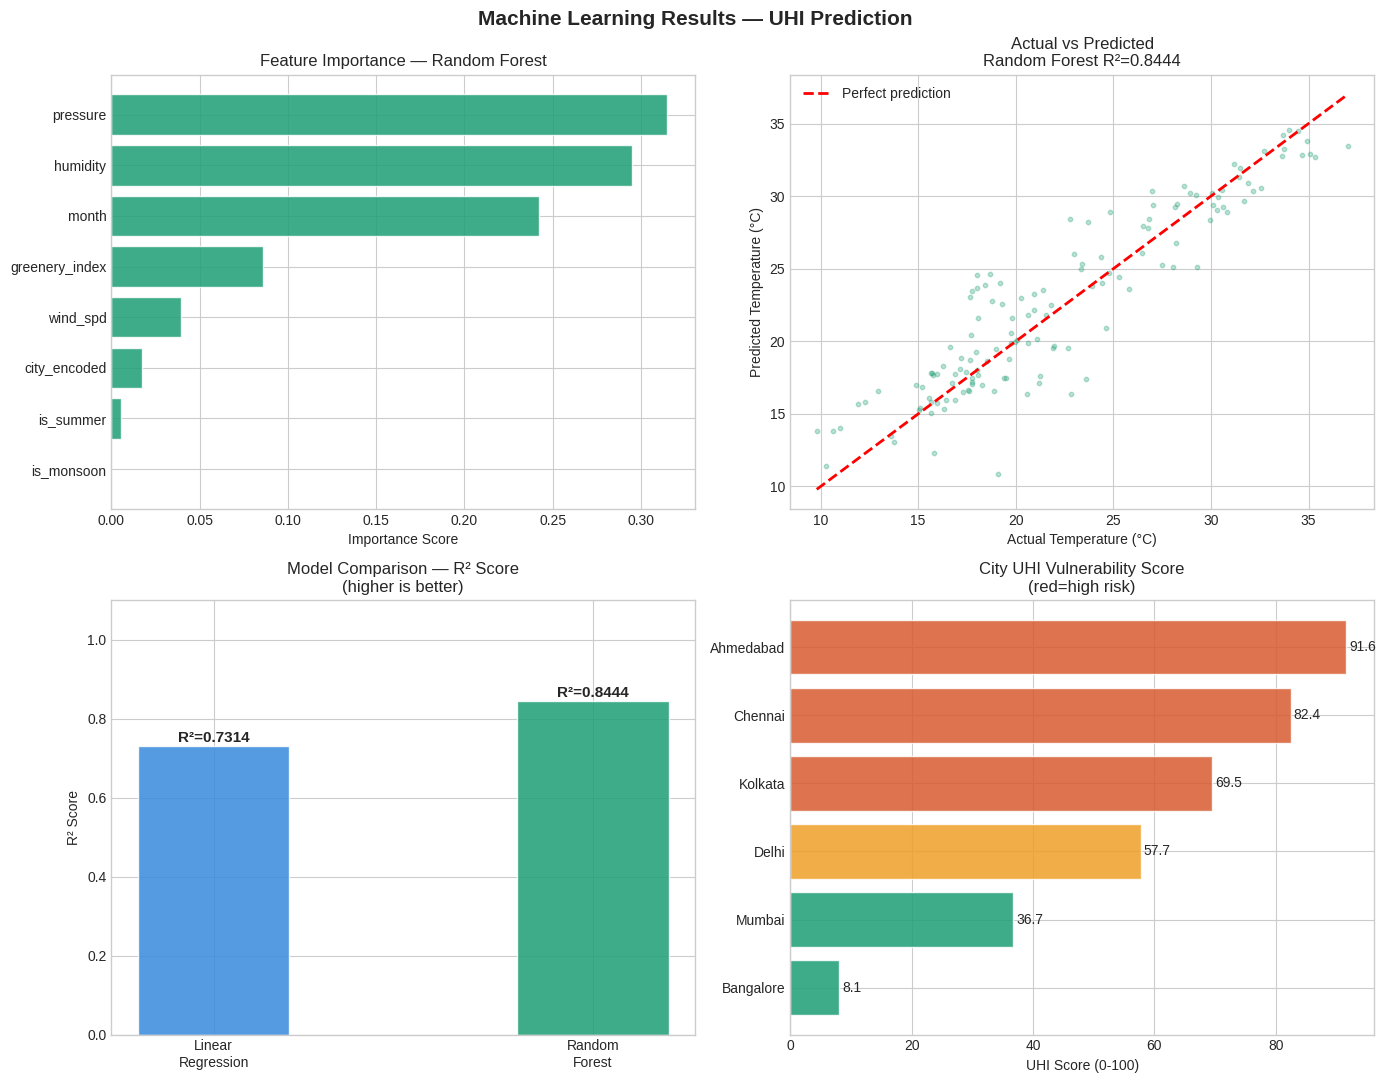


  ✓ ML results chart saved


In [22]:
fig3, axes = plt.subplots(2, 2, figsize=(14, 11))
fig3.suptitle('Machine Learning Results — UHI Prediction',
              fontsize=15, fontweight='bold')

# Plot 1: Feature importance
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)
axes[0, 0].barh(importances['feature'], importances['importance'],
                color='#1D9E75', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Feature Importance — Random Forest', fontsize=12)
axes[0, 0].set_xlabel('Importance Score')

# Plot 2: Actual vs Predicted
axes[0, 1].scatter(y_test, rf_pred, alpha=0.3, color='#1D9E75', s=10)
min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val],
                'r--', linewidth=2, label='Perfect prediction')
axes[0, 1].set_title(f'Actual vs Predicted\nRandom Forest R²={rf_r2:.4f}', fontsize=12)
axes[0, 1].set_xlabel('Actual Temperature (°C)')
axes[0, 1].set_ylabel('Predicted Temperature (°C)')
axes[0, 1].legend()

# Plot 3: Model comparison bar chart
model_names = ['Linear\nRegression', 'Random\nForest']
r2_scores = [lr_r2, rf_r2]
bar_colors = ['#378ADD', '#1D9E75']
bars = axes[1, 0].bar(model_names, r2_scores, color=bar_colors,
                      edgecolor='white', alpha=0.85, width=0.4)
for bar, val in zip(bars, r2_scores):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'R²={val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Model Comparison — R² Score\n(higher is better)', fontsize=12)
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_ylim(0, 1.1)

# Plot 4: City vulnerability ranking
vuln_colors = ['#D85A30' if s >= 60 else '#EF9F27' if s >= 40 else '#1D9E75'
               for s in city_vuln['uhi_score']]
h_bars = axes[1, 1].barh(city_vuln['city'], city_vuln['uhi_score'],
                          color=vuln_colors, edgecolor='white', alpha=0.85)
for bar, val in zip(h_bars, city_vuln['uhi_score']):
    axes[1, 1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}', va='center', fontsize=10)
axes[1, 1].set_title('City UHI Vulnerability Score\n(red=high risk)', fontsize=12)
axes[1, 1].set_xlabel('UHI Score (0-100)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/charts/ml_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n  ✓ ML results chart saved')

# Save vulnerability ranking for Power BI
city_vuln.to_excel('outputs/vulnerability_ranking_powerbi.xlsx', index=False)

---
## ✅ Final Summary

**Data Files (use in Power BI):**
- `outputs/uhi_cleaned_data.csv` — full cleaned dataset
- `outputs/city_summary_powerbi.xlsx` — city averages
- `outputs/monthly_trends_powerbi.xlsx` — monthly trends
- `outputs/vulnerability_ranking_powerbi.xlsx` — city rankings

**Charts (use in research paper):**
- `outputs/charts/week4_univariate_analysis.png`
- `outputs/charts/week5_bivariate_multivariate.png`
- `outputs/charts/ml_results.png`

In [23]:
print('=' * 60)
print('   ALL CODE COMPLETE!')
print('=' * 60)
print(f'  Linear Regression  — R²: {lr_r2:.4f}, RMSE: {lr_rmse:.4f}')
print(f'  Random Forest      — R²: {rf_r2:.4f}, RMSE: {rf_rmse:.4f}')
print(f'\n  Most vulnerable city:  {city_vuln.iloc[0]["city"]} (UHI score: {city_vuln.iloc[0]["uhi_score"]})')
print(f'  Least vulnerable city: {city_vuln.iloc[-1]["city"]} (UHI score: {city_vuln.iloc[-1]["uhi_score"]})')
print('\n  Next step: Download the Excel files from outputs/ and load in Power BI!')
print('=' * 60)

   ALL CODE COMPLETE!
  Linear Regression  — R²: 0.7314, RMSE: 3.3574
  Random Forest      — R²: 0.8444, RMSE: 2.5551

  Most vulnerable city:  Ahmedabad (UHI score: 91.6)
  Least vulnerable city: Bangalore (UHI score: 8.1)

  Next step: Download the Excel files from outputs/ and load in Power BI!
